# 1. Creando dataset balanceado

In [ ]:
# 1. Definir los nombres de las columnas (1 etiqueta + 18 características en SUSY)
columnas = ['etiqueta'] + [f'feature_{i}' for i in range(1, 19)]

print("Cargando el dataset original comprimido... (esto tomará unos segundos)")
df = pd.read_csv('../dataset/SUSY.csv.gz', compression='gzip', names=columnas)
print("Cargado")

# 2. Aislar las variables de interés
df_8_features = df[['etiqueta'] + [f'feature_{i}' for i in range(1, 9)]]

# 3. Muestreo estratégico y balanceado
df_muestra = df_8_features.groupby('etiqueta').sample(n=1000, random_state=42)

# 4. Verificación de integridad
print("\nDimensiones de la muestra final:", df_muestra.shape)
print("Distribución de clases:\n", df_muestra['etiqueta'].value_counts())

# 5. Crear el archivo de trabajo ligero
df_muestra.to_csv('../dataset/SUSY_2000_balanced.csv', index=False)
print("\nMuestra guardada exitosamente como 'SUSY_2000_balanced.csv'.")

# 2. Análisis Exploratorio y Topología de los Datos (EDA)

In [12]:
!pip install seaborn
!pip install scikit-learn
!pip install pandas

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 2.4 MB/s eta 0:00:00m eta 0:00:0136m0:00:01
  Using cached contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (355 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 3.1 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 2.6 MB/s eta 0:00:00 MB/s eta 0:00:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 1.8 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 3.6 MB/s eta 0:00:004.2 MB/s eta 0:00:01


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv('../dataset/SUSY_2000_balanced.csv')

## Matriz de correlación

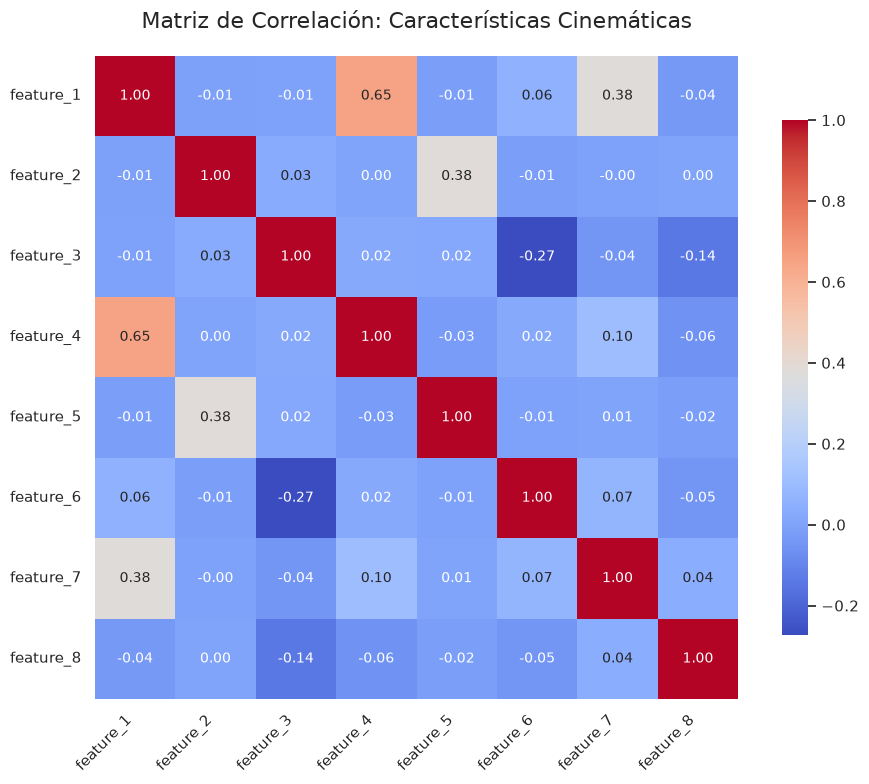

In [26]:
plt.figure(figsize=(10, 8))
correlacion = df.drop('etiqueta', axis=1).corr()


sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", 
            square=True, cbar_kws={"shrink": .8}, 
            annot_kws={"size": 10})

plt.title('Matriz de Correlación: Características Cinemáticas', fontsize=16, pad=20)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig('../img/matriz-correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

## Solapamiento de Clases

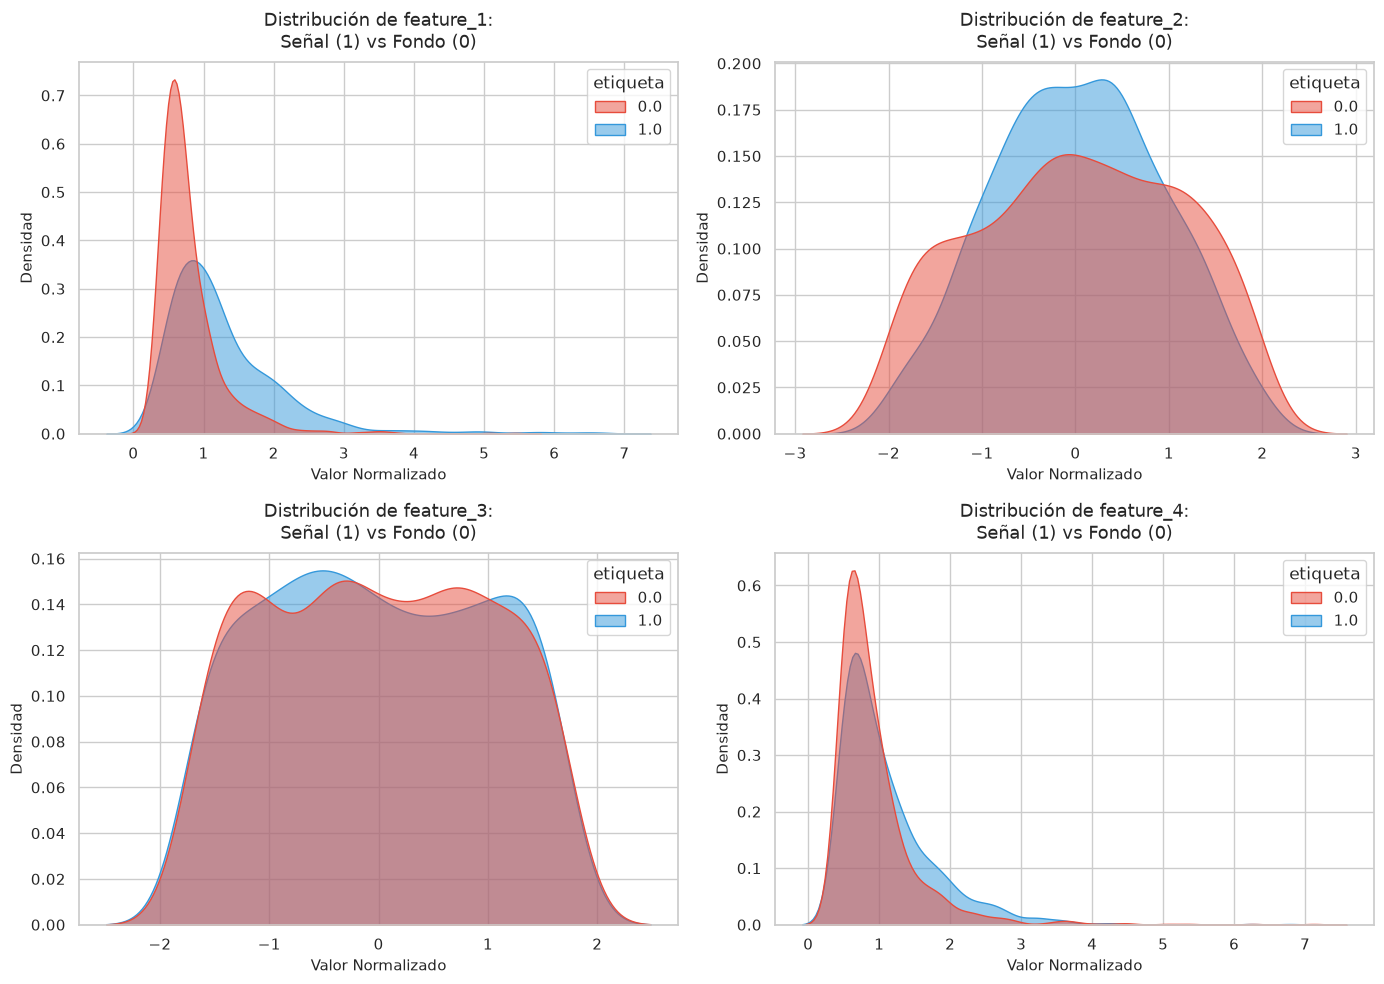

In [31]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

features_top = ['feature_1', 'feature_2', 'feature_3', 'feature_4']

for i, feature in enumerate(features_top):
    # Graficamos la densidad: 1.0 (Señal Supersimétrica) vs 0.0 (Ruido de Fondo)
    sns.kdeplot(
        data=df, 
        x=feature, 
        hue='etiqueta', 
        fill=True, 
        palette={0.0: '#e74c3c', 1.0: '#3498db'}, # Rojo oscuro para fondo, Azul para señal
        alpha=0.5,
        ax=axes[i]
    )
    
    # Configuramos los títulos y etiquetas de cada subgráfico
    axes[i].set_title(f'Distribución de {feature}:\nSeñal (1) vs Fondo (0)', fontsize=13, pad=10)
    axes[i].set_xlabel('Valor Normalizado', fontsize=11)
    axes[i].set_ylabel('Densidad', fontsize=11)

plt.tight_layout()
plt.savefig('../img/distribucion_clases_1_4.png', dpi=300, bbox_inches='tight')
plt.show()

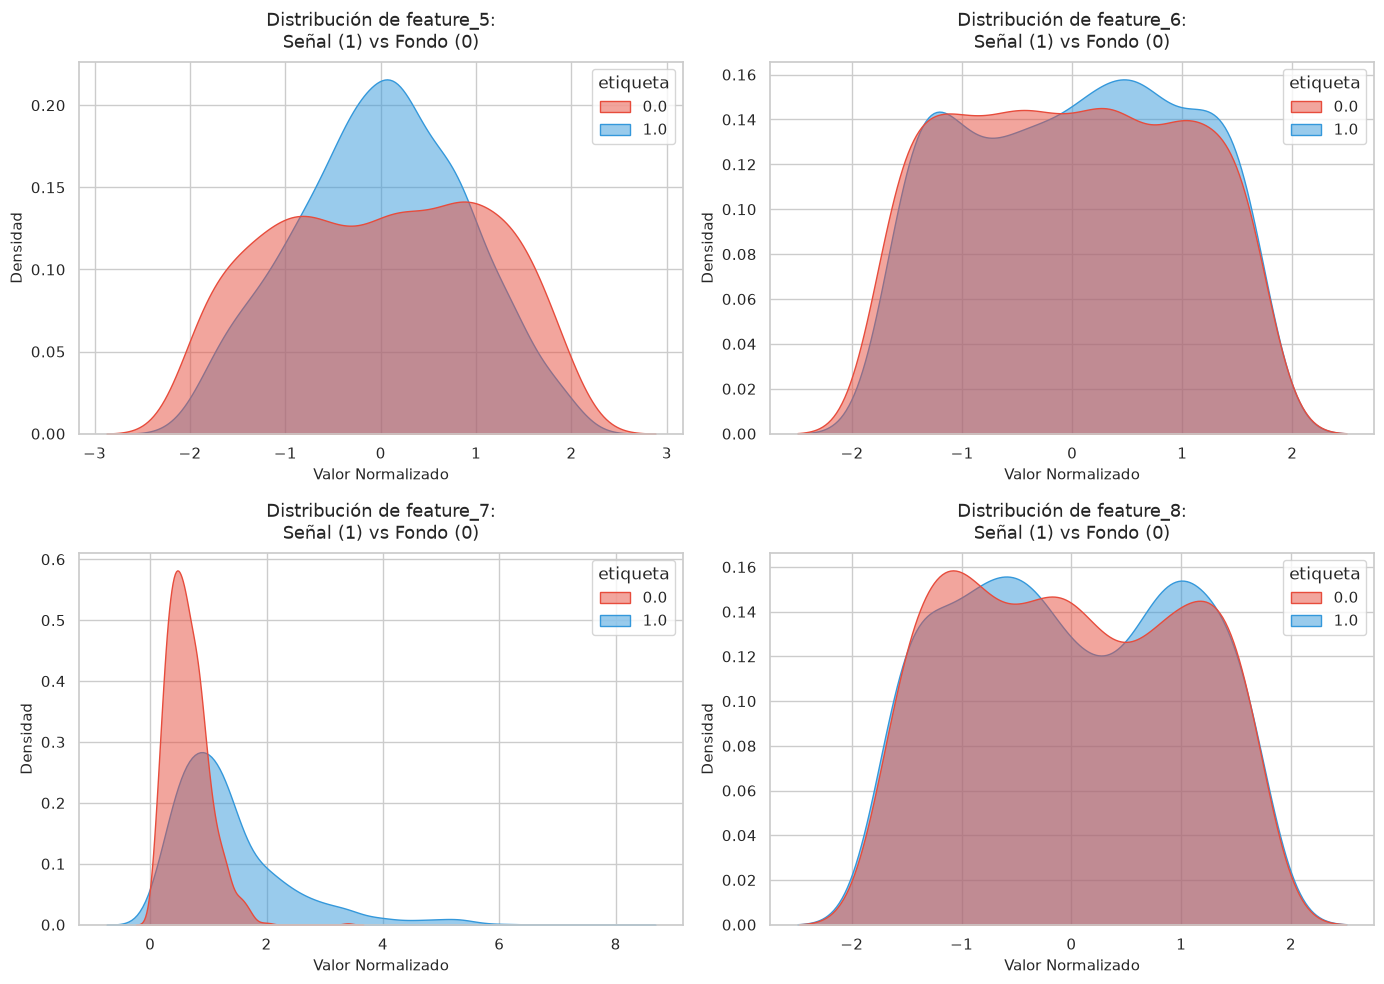

In [32]:
# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# Crear una figura amplia para alojar los 4 subgráficos restantes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Seleccionamos las características cinemáticas del 5 al 8
features_bottom = ['feature_5', 'feature_6', 'feature_7', 'feature_8']

for i, feature in enumerate(features_bottom):
    # Graficamos la densidad: 1.0 (Señal Supersimétrica) vs 0.0 (Ruido de Fondo)
    sns.kdeplot(
        data=df, 
        x=feature, 
        hue='etiqueta', 
        fill=True, 
        palette={0.0: '#e74c3c', 1.0: '#3498db'},
        alpha=0.5,
        ax=axes[i]
    )
    
    # Configuramos los títulos y etiquetas
    axes[i].set_title(f'Distribución de {feature}:\nSeñal (1) vs Fondo (0)', fontsize=13, pad=10)
    axes[i].set_xlabel('Valor Normalizado', fontsize=11)
    axes[i].set_ylabel('Densidad', fontsize=11)

# Ajustar el espaciado y guardar la imagen ANTES de mostrarla
plt.tight_layout()
plt.savefig('../img/distribucion_clases_5_8.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Comparativa Explícita de Kernels con validacion cruzada

In [34]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

# 1. Cargar la muestra estandarizada
print("Cargando la muestra balanceada...")
df = pd.read_csv('../dataset/SUSY_2000_balanced.csv')
X = df.drop('etiqueta', axis=1)
y = df['etiqueta']

# 2. Separar el conjunto de prueba (Hold-out del 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Construir el Pipeline (Vital para evitar fuga de información)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    # Activamos probability=True por si luego queremos graficar curvas ROC
    ('svm', SVC(random_state=42)) 
])

# 4. Definir el espacio de búsqueda (Grid)
# Evaluamos diferentes arquitecturas geométricas para el SVM
param_grid = [
    # Espacio Lineal
    {'svm__kernel': ['linear'], 'svm__C': [0.1, 1, 10]},
    # Espacio Polinómico (curvas)
    {'svm__kernel': ['poly'], 'svm__degree': [2, 3], 'svm__C': [0.1, 1, 10]},
    # Espacio RBF (alta no-linealidad)
    {'svm__kernel': ['rbf'], 'svm__C': [0.1, 1, 10], 'svm__gamma': ['scale', 0.1, 0.01]}
]

# 5. Configurar la Validación Cruzada
print("\nIniciando búsqueda exhaustiva de arquitecturas y parámetros...")
print("Esto entrenará 90 modelos en total (18 combinaciones x 5 pliegues).")
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1, # Exprime todos los núcleos del CPU
    scoring='accuracy',
    verbose=2  # Muestra el progreso en tiempo real
)

# 6. Ejecutar el entrenamiento masivo
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()

# 7. Imprimir el diagnóstico final
print(f"\n[+] Optimización completada en {(end_time - start_time):.2f} segundos.")
print("="*60)
print("LA MEJOR ARQUITECTURA CLÁSICA ENCONTRADA ES:")
print(grid_search.best_params_)
print(f"Precisión interna durante la validación (CV=5): {grid_search.best_score_ * 100:.2f}%")
print("="*60)

# 8. Prueba de fuego contra los datos aislados
mejor_modelo = grid_search.best_estimator_
y_pred = mejor_modelo.predict(X_test)
precision_final = accuracy_score(y_test, y_pred)

print(f"\nPrecisión estricta en el conjunto de prueba aislado: {precision_final * 100:.2f}%\n")
print("Reporte detallado de Clasificación:")
print(classification_report(y_test, y_pred))

Cargando la muestra balanceada...

Iniciando búsqueda exhaustiva de arquitecturas y parámetros...
Esto entrenará 90 modelos en total (18 combinaciones x 5 pliegues).
Fitting 5 folds for each of 18 candidates, totalling 90 fits

[+] Optimización completada en 1.10 segundos.
LA MEJOR ARQUITECTURA CLÁSICA ENCONTRADA ES:
{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Precisión interna durante la validación (CV=5): 76.50%

Precisión estricta en el conjunto de prueba aislado: 72.75%

Reporte detallado de Clasificación:
              precision    recall  f1-score   support

         0.0       0.69      0.82      0.75       199
         1.0       0.78      0.64      0.70       201

    accuracy                           0.73       400
   macro avg       0.74      0.73      0.73       400
weighted avg       0.74      0.73      0.73       400

[CV] END .......................svm__C=1, svm__kernel=linear; total time=   0.3s
[CV] END ......................svm__C=10, svm__kernel=linear; t

Cargando y preparando el dataset...

Iniciando entrenamiento y evaluación cruzada de arquitecturas...

------------------------------------------------------------
Entrenando arquitectura: LINEAR
Tiempo de entrenamiento: 0.0425 segundos
Precisión (Accuracy): 73.75%
Área bajo la curva (AUC): 0.7968
------------------------------------------------------------
Entrenando arquitectura: POLY
Tiempo de entrenamiento: 0.0357 segundos
Precisión (Accuracy): 71.25%
Área bajo la curva (AUC): 0.7892
------------------------------------------------------------
Entrenando arquitectura: SIGMOID
Tiempo de entrenamiento: 0.0499 segundos
Precisión (Accuracy): 64.25%
Área bajo la curva (AUC): 0.6806
------------------------------------------------------------
Entrenando arquitectura: RBF
Tiempo de entrenamiento: 0.0475 segundos
Precisión (Accuracy): 72.00%
Área bajo la curva (AUC): 0.7998
------------------------------------------------------------


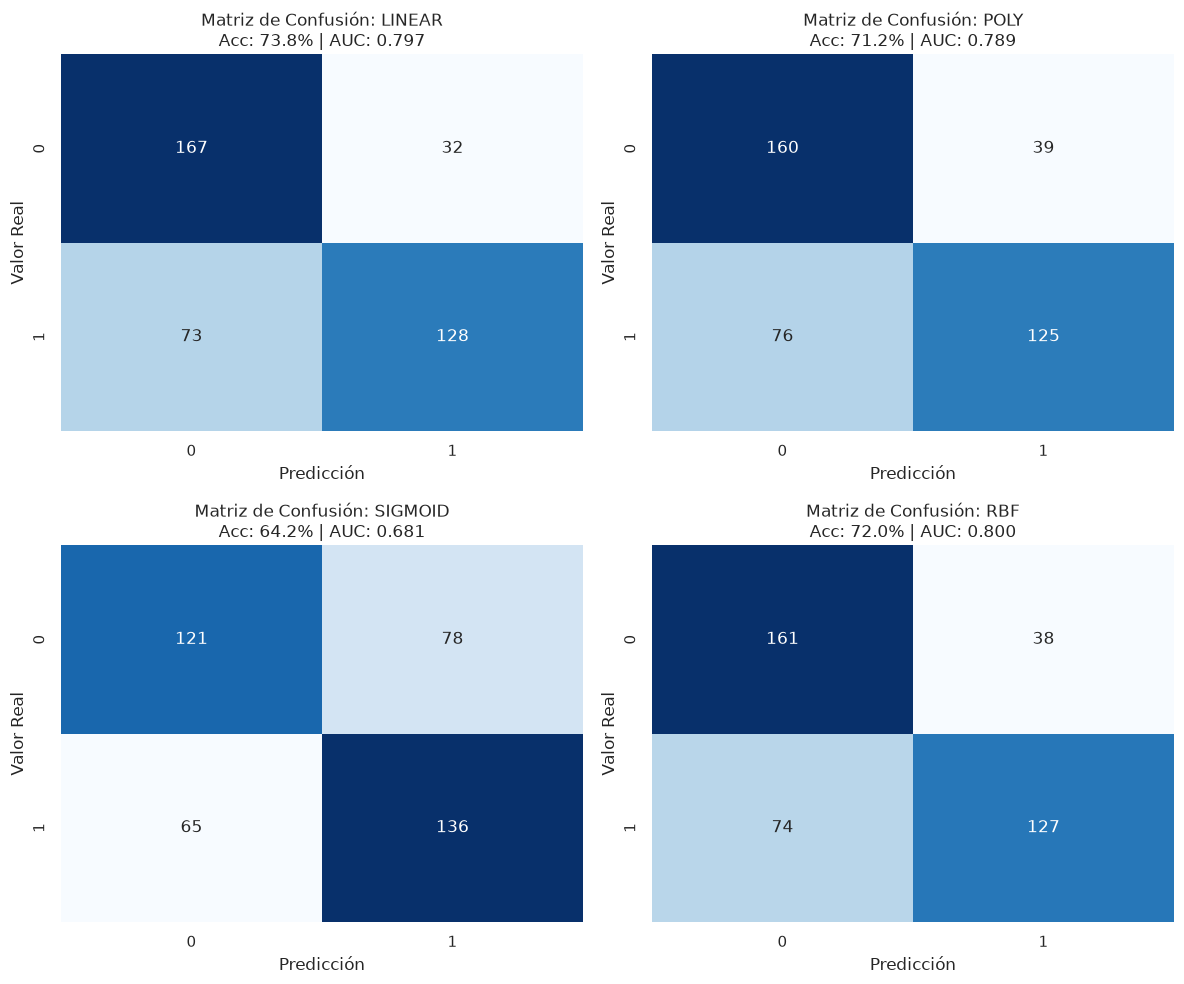

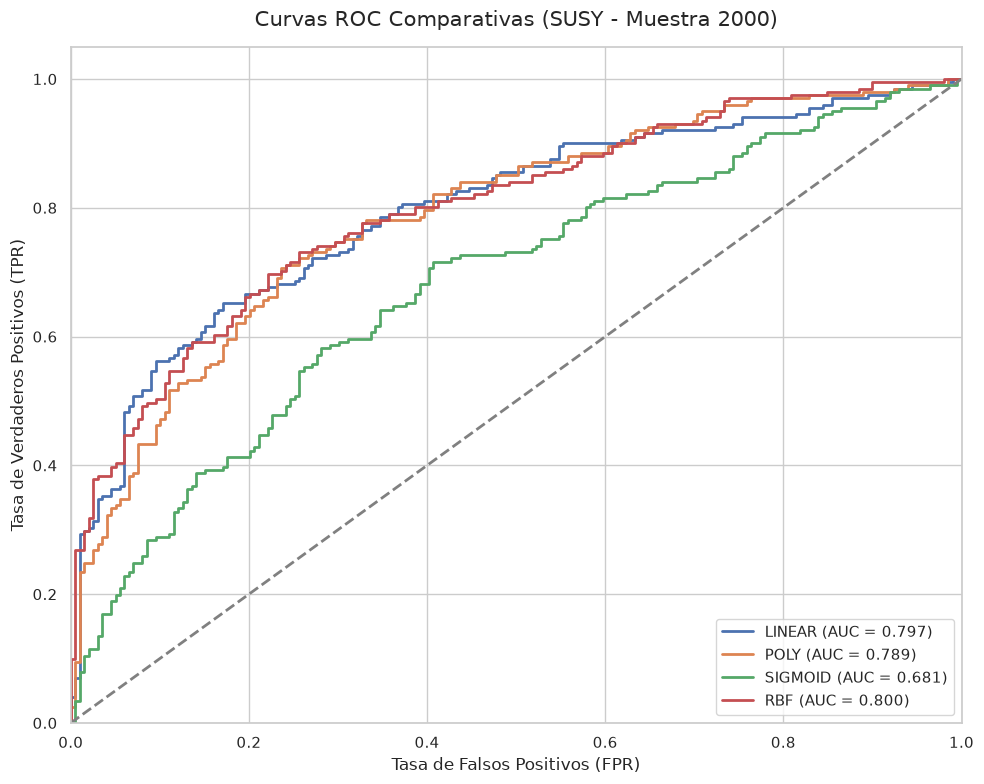

Las gráficas de alta resolución han sido guardadas en el directorio.


In [36]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# 1. Preparación de los Datos
print("Cargando y preparando el dataset...")
df = pd.read_csv('../dataset/SUSY_2000_balanced.csv')
X = df.drop('etiqueta', axis=1)
y = df['etiqueta']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Estandarización estricta (evitando data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Definición de las Arquitecturas a evaluar
kernels = ['linear', 'poly', 'sigmoid', 'rbf']
resultados = {}

# Configuración de figuras
sns.set_theme(style="whitegrid")
fig_cm, axes_cm = plt.subplots(2, 2, figsize=(12, 10))
axes_cm = axes_cm.flatten()

plt.figure(figsize=(10, 8)) # Figura independiente para la Curva ROC
ax_roc = plt.gca()

print("\nIniciando entrenamiento y evaluación cruzada de arquitecturas...\n")
print("-" * 60)

# 3. Ciclo Principal de Entrenamiento y Extracción de Métricas
for i, kernel in enumerate(kernels):
    print(f"Entrenando arquitectura: {kernel.upper()}")
    
    # Instanciamos el modelo con el kernel actual
    modelo = SVC(kernel=kernel, random_state=42)
    
    # Medición exacta del tiempo de convergencia
    start_time = time.time()
    modelo.fit(X_train_scaled, y_train)
    end_time = time.time()
    tiempo_ejecucion = end_time - start_time
    
    # Predicciones y distancias al hiperplano (decision_function)
    y_pred = modelo.predict(X_test_scaled)
    y_scores = modelo.decision_function(X_test_scaled)
    
    # Métricas de rendimiento
    acc = accuracy_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # Almacenamos resultados para análisis
    resultados[kernel] = {'tiempo': tiempo_ejecucion, 'acc': acc, 'auc': roc_auc}
    
    # Reporte en consola
    print(f"Tiempo de entrenamiento: {tiempo_ejecucion:.4f} segundos")
    print(f"Precisión (Accuracy): {acc * 100:.2f}%")
    print(f"Área bajo la curva (AUC): {roc_auc:.4f}")
    print("-" * 60)
    
    # --- Generación de Gráficos ---
    
    # 1. Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[i], cbar=False,
                annot_kws={"size": 12})
    axes_cm[i].set_title(f'Matriz de Confusión: {kernel.upper()}\nAcc: {acc*100:.1f}% | AUC: {roc_auc:.3f}', fontsize=12)
    axes_cm[i].set_xlabel('Predicción')
    axes_cm[i].set_ylabel('Valor Real')
    
    # 2. Añadir curva a la gráfica ROC maestra
    ax_roc.plot(fpr, tpr, lw=2, label=f'{kernel.upper()} (AUC = {roc_auc:.3f})')

# --- Ajustes finales de las figuras ---

# Guardar Matrices de Confusión
fig_cm.tight_layout()
fig_cm.savefig('../img/matrices_confusion_comparativa.png', dpi=300, bbox_inches='tight')

# Configurar y guardar Curva ROC maestra
ax_roc.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--') # Línea de adivinanza aleatoria
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax_roc.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax_roc.set_title('Curvas ROC Comparativas (SUSY - Muestra 2000)', fontsize=15, pad=15)
ax_roc.legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.savefig('../img/curva_roc_comparativa.png', dpi=300, bbox_inches='tight')

# Mostrar todas las gráficas renderizadas
plt.show()

print("Las gráficas de alta resolución han sido guardadas en el directorio.")

In [37]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# 1. Preparación de los datos estandarizada
df = pd.read_csv('../dataset/SUSY_2000_balanced.csv')
X = df.drop('etiqueta', axis=1)
y = df['etiqueta']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Configurar las mallas de búsqueda de hiperparámetros por separado
espacios_busqueda = {
    'LINEAR': {
        'svm__kernel': ['linear'],
        'svm__C': [0.01, 0.1, 1, 10, 100]
    },
    'RBF': {
        'svm__kernel': ['rbf'],
        'svm__C': [0.1, 1, 10, 100, 1000],
        'svm__gamma': ['scale', 'auto', 0.1, 0.01, 0.001]
    }
}

# 3. Búsqueda exhaustiva y extracción de métricas
for nombre, parametros in espacios_busqueda.items():
    print(f"\n{'='*60}\nOptimizando Arquitectura: {nombre}\n{'='*60}")
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(random_state=42))
    ])
    
    # n_jobs=-1 exprime todos los núcleos del procesador
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=parametros,
        cv=5,
        n_jobs=-1,
        scoring='accuracy',
        verbose=1
    )
    
    start_time = time.time()
    grid.fit(X_train, y_train)
    tiempo_opt = time.time() - start_time
    
    # 4. Evaluación del modelo campeón de cada arquitectura
    mejor_modelo = grid.best_estimator_
    y_pred = mejor_modelo.predict(X_test)
    y_scores = mejor_modelo.decision_function(X_test) # Distancias para calcular AUC
    
    acc = accuracy_score(y_test, y_pred)
    auc_val = roc_auc_score(y_test, y_scores)
    
    print(f"Tiempo total de validación cruzada: {tiempo_opt:.2f} segundos")
    print("\nMEJORES HIPERPARÁMETROS ENCONTRADOS:")
    print(grid.best_params_)
    print(f"\n--- MÉTRICAS DE RENDIMIENTO ESTRICTO ({nombre}) ---")
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"AUC (Capacidad de discriminación ROC): {auc_val:.4f}")
    print("\nReporte Detallado de Errores (Falsos Positivos / Negativos):")
    print(classification_report(y_test, y_pred))


Optimizando Arquitectura: LINEAR
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Tiempo total de validación cruzada: 3.68 segundos

MEJORES HIPERPARÁMETROS ENCONTRADOS:
{'svm__C': 10, 'svm__kernel': 'linear'}

--- MÉTRICAS DE RENDIMIENTO ESTRICTO (LINEAR) ---
Accuracy: 73.50%
AUC (Capacidad de discriminación ROC): 0.7964

Reporte Detallado de Errores (Falsos Positivos / Negativos):
              precision    recall  f1-score   support

         0.0       0.69      0.83      0.76       199
         1.0       0.80      0.64      0.71       201

    accuracy                           0.73       400
   macro avg       0.74      0.74      0.73       400
weighted avg       0.75      0.73      0.73       400


Optimizando Arquitectura: RBF
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Tiempo total de validación cruzada: 4.38 segundos

MEJORES HIPERPARÁMETROS ENCONTRADOS:
{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}

--- MÉTRICAS DE RENDIMIENTO ESTRICT

In [40]:
import pandas as pd

# Leemos solo 5 filas, sin imponer nombres ni formatos, para ver la matriz real
df_debug = pd.read_csv('../dataset/SUSY.csv.gz', compression='gzip', header=None, nrows=5)

print("Dimensiones reales leídas:", df_debug.shape)
print("\nPrimeras 5 filas crudas:")
print(df_debug)

Dimensiones reales leídas: (5, 19)

Primeras 5 filas crudas:
    0         1         2         3         4         5         6         7   \
0  0.0  0.972861  0.653855  1.176225  1.157156 -1.739873 -0.874309  0.567765   
1  1.0  1.667973  0.064191 -1.225171  0.506102 -0.338939  1.672543  3.475464   
2  1.0  0.444840 -0.134298 -0.709972  0.451719 -1.613871 -0.768661  1.219918   
3  1.0  0.381256 -0.976145  0.693152  0.448959  0.891753 -0.677328  2.033060   
4  1.0  1.309996 -0.690089 -0.676259  1.589283 -0.693326  0.622907  1.087562   

         8         9         10        11        12        13        14  \
0 -0.175000  0.810061 -0.252552  1.921887  0.889637  0.410772  1.145621   
1 -1.219136  0.012955  3.775174  1.045977  0.568051  0.481928  0.000000   
2  0.504026  1.831248 -0.431385  0.526283  0.941514  1.587535  2.024308   
3  1.533041  3.046260 -1.005285  0.569386  1.015211  1.582217  1.551914   
4 -0.381742  0.589204  1.365479  1.179295  0.968218  0.728563  0.000000   

       

Cargando y alineando el dataset original SUSY (19 columnas)...
Extrayendo 10,000 registros de cada clase para el test de estrés...

Iniciando test de escalabilidad (esto tomará varios minutos)...
Entrenando LINEAR (C=10) con 500 datos...
Entrenando RBF (C=100, gamma=0.01) con 500 datos...
Entrenando LINEAR (C=10) con 1000 datos...
Entrenando RBF (C=100, gamma=0.01) con 1000 datos...
Entrenando LINEAR (C=10) con 2000 datos...
Entrenando RBF (C=100, gamma=0.01) con 2000 datos...
Entrenando LINEAR (C=10) con 5000 datos...
Entrenando RBF (C=100, gamma=0.01) con 5000 datos...
Entrenando LINEAR (C=10) con 10000 datos...
Entrenando RBF (C=100, gamma=0.01) con 10000 datos...
Entrenando LINEAR (C=10) con 16000 datos...
Entrenando RBF (C=100, gamma=0.01) con 16000 datos...


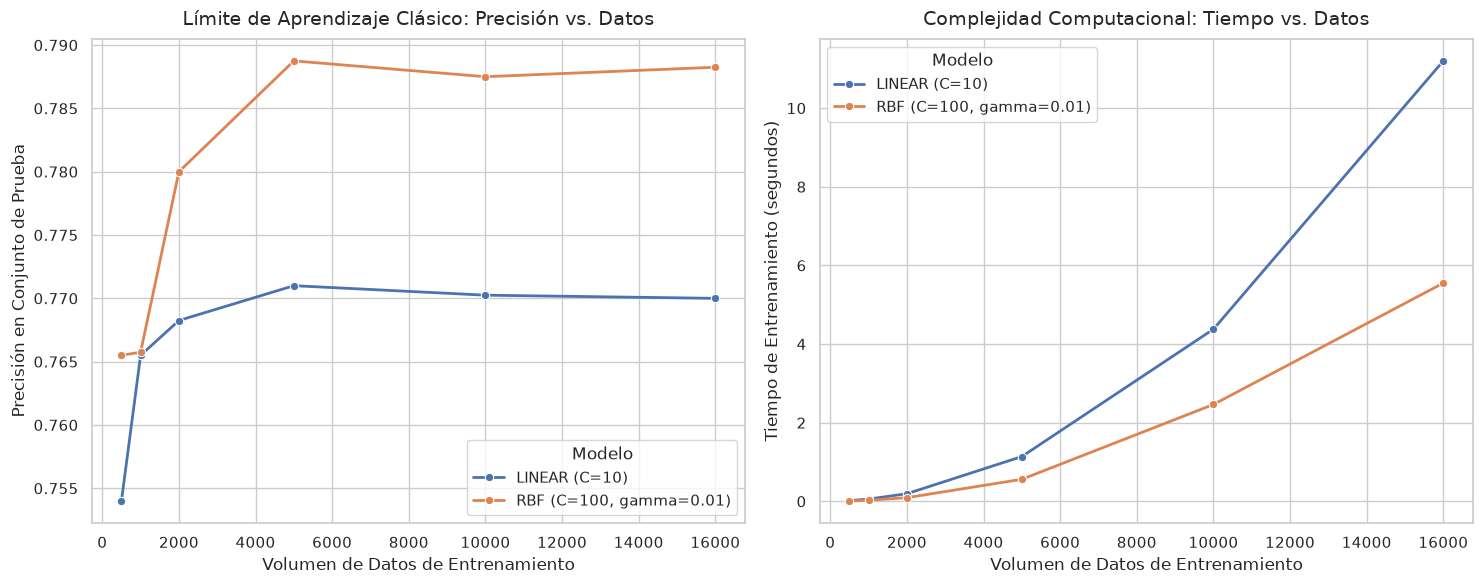


Diagnóstico completado. Gráfica guardada como 'limite_clasico_diagnostico.png'.


In [41]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print("Cargando y alineando el dataset original SUSY (19 columnas)...")
# 1. Nombramos TODAS las 19 columnas para evitar el desplazamiento
columnas_completas = ['etiqueta'] + [f'feature_{i}' for i in range(1, 19)]
df_full = pd.read_csv('../dataset/SUSY.csv.gz', compression='gzip', names=columnas_completas)

# 2. Aislamos exclusivamente la etiqueta y las 8 características cinemáticas para el proyecto
df_8_features = df_full[['etiqueta'] + [f'feature_{i}' for i in range(1, 9)]]

print("Extrayendo 10,000 registros de cada clase para el test de estrés...")
# 3. Muestreo seguro de 20,000 datos (10k por clase)
df_pool = df_8_features.groupby('etiqueta').sample(n=10000, random_state=42)
X_pool = df_pool.drop('etiqueta', axis=1)
y_pool = df_pool['etiqueta']

# Separamos un 20% estático (4,000 datos) para medir la precisión de todos los incrementos justamente
X_train_full, X_test, y_train_full, y_test = train_test_split(X_pool, y_pool, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

# Incrementos de datos a evaluar para trazar las curvas
tamanos = [500, 1000, 2000, 5000, 10000, 16000]
resultados = []

# Los modelos configurados con la arquitectura campeona del Paso 4
modelos = {
    'LINEAR (C=10)': SVC(kernel='linear', C=10, random_state=42),
    'RBF (C=100, gamma=0.01)': SVC(kernel='rbf', C=100, gamma=0.01, random_state=42)
}

print("\nIniciando test de escalabilidad (esto tomará varios minutos)...")

for tamano in tamanos:
    X_sub = X_train_full_scaled[:tamano]
    y_sub = y_train_full[:tamano]
    
    for nombre, modelo in modelos.items():
        print(f"Entrenando {nombre} con {tamano} datos...")
        start_time = time.time()
        modelo.fit(X_sub, y_sub)
        tiempo = time.time() - start_time
        
        y_pred = modelo.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        
        resultados.append({'Tamaño': tamano, 'Modelo': nombre, 'Tiempo (s)': tiempo, 'Accuracy': acc})

df_res = pd.DataFrame(resultados)

# --- Generación de Gráficas de Diagnóstico ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfica 1: Curva de Aprendizaje (Asíntota)
sns.lineplot(data=df_res, x='Tamaño', y='Accuracy', hue='Modelo', marker='o', lw=2, ax=axes[0])
axes[0].set_title('Límite de Aprendizaje Clásico: Precisión vs. Datos', fontsize=14, pad=10)
axes[0].set_xlabel('Volumen de Datos de Entrenamiento')
axes[0].set_ylabel('Precisión en Conjunto de Prueba')

# Gráfica 2: Explosión Temporal
sns.lineplot(data=df_res, x='Tamaño', y='Tiempo (s)', hue='Modelo', marker='o', lw=2, ax=axes[1])
axes[1].set_title('Complejidad Computacional: Tiempo vs. Datos', fontsize=14, pad=10)
axes[1].set_xlabel('Volumen de Datos de Entrenamiento')
axes[1].set_ylabel('Tiempo de Entrenamiento (segundos)')

plt.tight_layout()
plt.savefig('../img/limite_clasico_diagnostico.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nDiagnóstico completado. Gráfica guardada como 'limite_clasico_diagnostico.png'.")

In [42]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

print("Extrayendo 6,000 registros balanceados del archivo original...")
columnas_completas = ['etiqueta'] + [f'feature_{i}' for i in range(1, 19)]
df_full = pd.read_csv('../dataset/SUSY.csv.gz', compression='gzip', names=columnas_completas)

# Aislamiento de variables y extracción
df_8_features = df_full[['etiqueta'] + [f'feature_{i}' for i in range(1, 9)]]
df_pool = df_8_features.groupby('etiqueta').sample(n=3000, random_state=42)

X = df_pool.drop('etiqueta', axis=1)
y = df_pool['etiqueta']

# Hold-out del 20% para la prueba final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mallas de búsqueda expandidas
espacios_busqueda = {
    'LINEAR': {
        'svm__kernel': ['linear'],
        'svm__C': [0.01, 0.1, 1, 10, 100, 1000] # Búsqueda de penalización extrema
    },
    'POLY': {
        'svm__kernel': ['poly'],
        'svm__degree': [2, 3, 4], # Evaluando curvas más complejas
        'svm__C': [0.1, 1, 10, 100]
    },
    'RBF': {
        'svm__kernel': ['rbf'],
        'svm__C': [0.1, 1, 10, 100, 1000],
        'svm__gamma': ['scale', 'auto', 1, 0.1, 0.01, 0.001] # Espectro completo de influencia
    }
}

for nombre, parametros in espacios_busqueda.items():
    print(f"\n{'='*65}\nIniciando Búsqueda Masiva: Arquitectura {nombre}\n{'='*65}")
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(random_state=42))
    ])
    
    # Validación cruzada de 10 pliegues (cv=10)
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=parametros,
        cv=10, 
        n_jobs=-1,
        scoring='accuracy',
        verbose=1
    )
    
    start_time = time.time()
    grid.fit(X_train, y_train)
    tiempo_opt = time.time() - start_time
    
    # Evaluación rigurosa
    mejor_modelo = grid.best_estimator_
    y_pred = mejor_modelo.predict(X_test)
    y_scores = mejor_modelo.decision_function(X_test) 
    
    acc = accuracy_score(y_test, y_pred)
    auc_val = roc_auc_score(y_test, y_scores)
    
    print(f"Tiempo total de búsqueda y validación: {tiempo_opt:.2f} segundos")
    print("\n[+] MEJORES HIPERPARÁMETROS ENCONTRADOS:")
    print(grid.best_params_)
    print(f"\n--- MÉTRICAS DE RENDIMIENTO ESTRICTO ({nombre}) ---")
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"AUC: {auc_val:.4f}")
    print("\nReporte Detallado:")
    print(classification_report(y_test, y_pred))

Extrayendo 6,000 registros balanceados del archivo original...

Iniciando Búsqueda Masiva: Arquitectura LINEAR
Fitting 10 folds for each of 6 candidates, totalling 60 fits
Tiempo total de búsqueda y validación: 153.81 segundos

[+] MEJORES HIPERPARÁMETROS ENCONTRADOS:
{'svm__C': 1000, 'svm__kernel': 'linear'}

--- MÉTRICAS DE RENDIMIENTO ESTRICTO (LINEAR) ---
Accuracy: 75.83%
AUC: 0.8160

Reporte Detallado:
              precision    recall  f1-score   support

         0.0       0.72      0.86      0.78       613
         1.0       0.82      0.65      0.72       587

    accuracy                           0.76      1200
   macro avg       0.77      0.76      0.75      1200
weighted avg       0.77      0.76      0.76      1200


Iniciando Búsqueda Masiva: Arquitectura POLY
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Tiempo total de búsqueda y validación: 44.92 segundos

[+] MEJORES HIPERPARÁMETROS ENCONTRADOS:
{'svm__C': 1, 'svm__degree': 3, 'svm__kernel': 'poly'}

-